# Task 8: Household Energy Consumption Forecasting

## Objective

Forecast household electricity usage using historical time-series data.

## Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [21]:
df = pd.read_csv("household_power_consumption.txt", sep=';')

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


## Data Cleaning + Datetime Fix

In [22]:
# Replace missing values
df.replace("?", np.nan, inplace=True)

# Combine Date + Time
df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"], dayfirst=True)

df.set_index("DateTime", inplace=True)

# Drop old columns
df.drop(["Date", "Time"], axis=1, inplace=True)

# Convert all columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop missing values
df.dropna(inplace=True)

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Resampling

In [23]:
df_hourly = df.resample("H").mean()

df_hourly = df_hourly[["Global_active_power"]]

df_hourly.head()

,Global_active_power
DateTime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


## Visualization

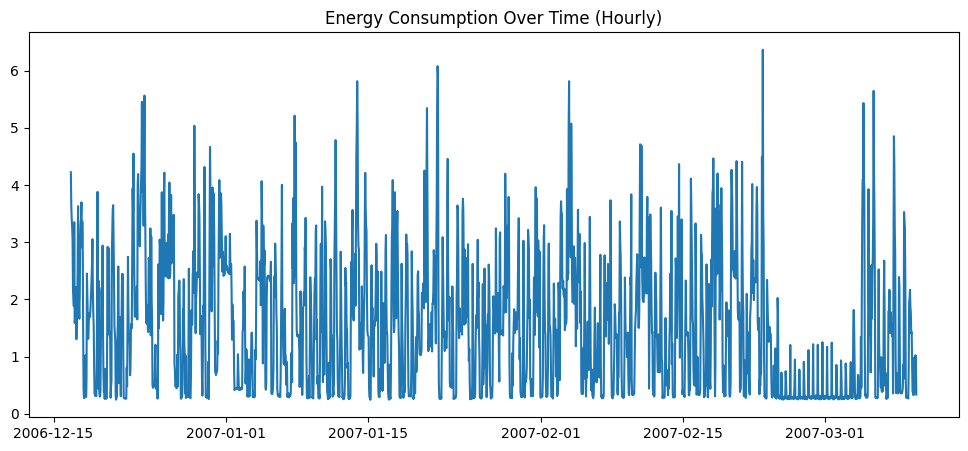

In [24]:
plt.figure(figsize=(12,5))
plt.plot(df_hourly.index[:2000], df_hourly["Global_active_power"][:2000])
plt.title("Energy Consumption Over Time (Hourly)")
plt.show()

## Feature Engineering

In [25]:
df_hourly["hour"] = df_hourly.index.hour
df_hourly["dayofweek"] = df_hourly.index.dayofweek
df_hourly["is_weekend"] = (df_hourly["dayofweek"] >= 5).astype(int)

# Lag features (VERY important for ML models)
df_hourly["lag_1"] = df_hourly["Global_active_power"].shift(1)
df_hourly["lag_24"] = df_hourly["Global_active_power"].shift(24)

df_hourly.dropna(inplace=True)

## Train-Test Split

In [26]:
train_size = int(len(df_hourly) * 0.8)

train = df_hourly[:train_size]
test = df_hourly[train_size:]

X_train = train.drop("Global_active_power", axis=1)
y_train = train["Global_active_power"]

X_test = test.drop("Global_active_power", axis=1)
y_test = test["Global_active_power"]

## MODEL 1 — ARIMA

### ARIMA Model

In [27]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train["Global_active_power"], order=(2,1,2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

## Evaluation

In [28]:
mae_arima = mean_absolute_error(y_test, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(y_test, arima_pred))

mae_arima, rmse_arima

(0.7899681924109693, np.float64(0.9132845602659219))

## MODEL 2 — PROPHET

### Prophet Model

In [29]:
from prophet import Prophet

prophet_df = df_hourly[["Global_active_power"]].reset_index()
prophet_df.columns = ["ds", "y"]

train_p = prophet_df.iloc[:train_size]
test_p = prophet_df.iloc[train_size:]

model = Prophet()
model.fit(train_p)

future = model.make_future_dataframe(periods=len(test_p), freq="H")
forecast = model.predict(future)

prophet_pred = forecast["yhat"].iloc[-len(test_p):].values

23:18:58 - cmdstanpy - INFO - Chain [1] start processing
23:19:11 - cmdstanpy - INFO - Chain [1] done processing


## Evaluation

In [30]:
mae_prophet = mean_absolute_error(test_p["y"], prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test_p["y"], prophet_pred))

mae_prophet, rmse_prophet

(0.6543122804407815, np.float64(0.8253509617605662))

## MODEL 3 — XGBOOST

### Model Training

In [31]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6
)

model_xgb.fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_test)

### XGBoost Evaluation

In [32]:
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

### MODEL COMPARISON

In [33]:
results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "XGBoost"],
    "MAE": [mae_arima, mae_prophet, mae_xgb],
    "RMSE": [rmse_arima, rmse_prophet, rmse_xgb]
})

results

,Model,MAE,RMSE
0,ARIMA,0.789968,0.913285
1,Prophet,0.654312,0.825351
2,XGBoost,0.343173,0.493455


### VISUALIZATION

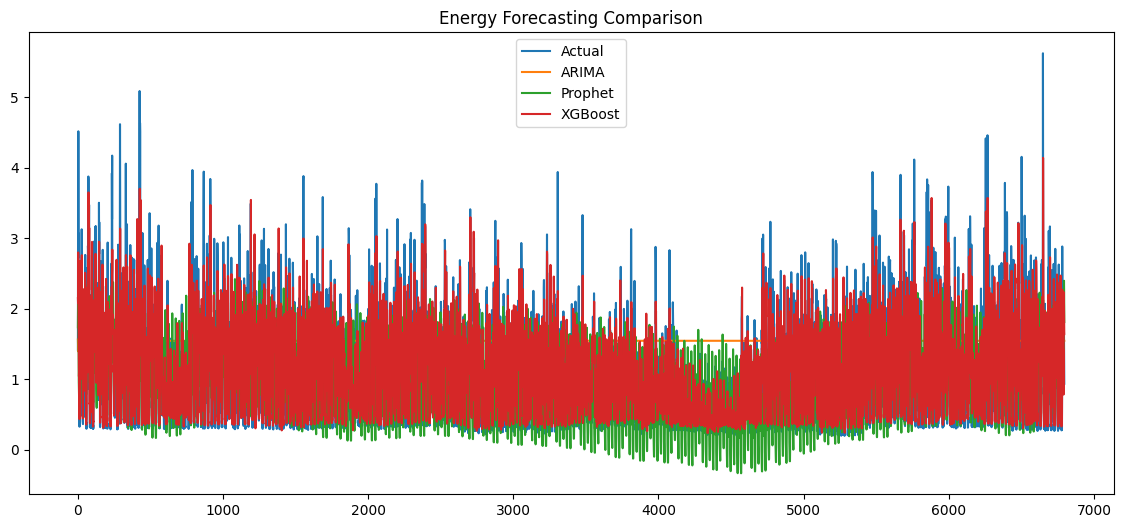

In [34]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual")
plt.plot(arima_pred.values, label="ARIMA")
plt.plot(prophet_pred, label="Prophet")
plt.plot(xgb_pred, label="XGBoost")

plt.legend()
plt.title("Energy Forecasting Comparison")
plt.show()

## INSIGHTS

- Energy usage is highly time-dependent (hourly + daily cycles)
- ARIMA works for simple patterns only
- Prophet handles seasonality well
- XGBoost performs best due to lag features + non-linear learning

## CONCLUSION

- Time series forecasting improves significantly with feature engineering
- Machine learning models outperform classical models in this dataset
- XGBoost is the most accurate model for prediction

_____________________________